In [19]:
# This notebook is self-contained: it loads raw data directly rather than from the
# feature store. EDA precedes all pipeline decisions and requires no preprocessing —
# every transformation shown here is for visual motivation only, not model input.
#
# All other notebooks load from data/feature_store/, which is generated by
# data_sanity.ipynb after asserting the findings documented here.

# Exploratory Data Analysis

This notebook documents our findings from the raw dataset. It is intentionally self-contained:
all transformations shown here are for visual motivation only and involve no statistical fitting.

The findings established here serve two downstream purposes. First, they are formally asserted
in `data_sanity.ipynb`, which validates each quantitative claim programmatically and writes
the feature matrices (`F_E.pkl`, `F_B.pkl`) and targets to `data/feature_store/` as the single
source of truth for all model notebooks. Second, they directly motivate every feature
engineering and preprocessing decision documented in the methodology.

---

## Goal: Recommendation System / Next Best Action

The end objective is a two-stage pipeline. The first stage identifies clients with high
investment propensity by classifying each client on two binary targets:
`AccumulationInvestment` (preference for systematic dollar-cost averaging) and
`IncomeInvestment` (preference for lump-sum deployment of accumulated capital). The second
stage matches each identified client to the most suitable product from the catalog, using
investment need type and risk compatibility as matching criteria. The combined output — a
ranked list of client-product pairs — constitutes the Next Best Action for the advisory team.

Before any model can be built, the data must be understood. The sections below establish the
distributional properties, class balance, feature-target relationships, and correlation
structure that inform every subsequent modeling decision.

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
# Load each sheet into separate DataFrames
current_dir = Path.cwd()
file_path = current_dir / 'Data' / 'Dataset2_Needs.xls'

# Load each sheet into separate DataFrames
needs_df = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

## Data Exploration & Feature Engineering

The dataset contains 5,000 clients, 9 raw features, and 2 binary targets, with no missing values.
Before touching any model, we explore the data along three axes: distributions and class balance,
outlier structure, and feature-target relationships. Every visualization is chosen to motivate a
specific modeling or engineering decision — not for descriptive completeness.


In [3]:
# Let's see the actual variables names in metadata_df
print("Metadata DataFrame columns:")
print(metadata_df.columns.tolist())

# Let's peek at the first few rows
print("\nFirst few rows of metadata:")
print(metadata_df.head())


Metadata DataFrame columns:
['Metadata', 'Unnamed: 1']

First few rows of metadata:
        Metadata                     Unnamed: 1
0        Clients                            NaN
1             ID                   Numerical ID
2            Age                  Age, in years
3         Gender  Gender (Female = 1, Male = 0)
4  FamilyMembers           Number of components


In [13]:
metadata_df

,Metadata,Unnamed: 1
0,Clients,NaN
1,ID,Numerical ID
2,Age,"Age, in years"
3,Gender,"Gender (Female = 1, Male = 0)"
4,FamilyMembers,Number of components
5,FinancialEducation,Normalized level of Financial Education (estim...
6,RiskPropensity,Normalized Risk propensity from MIFID profile
7,Income,Income (thousands of euros); estimate
8,Wealth,Wealth (thousands of euros); sum of investment...
9,IncomeInvestment,Boolean variable for Income investment; 1 = Hi...


In [4]:
# Drop ID column as it's not needed for analysis
needs_df = needs_df.drop('ID', axis=1)

In [5]:
def create_variable_summary(df, metadata_df):
    # Create empty lists to store the chosen statistics
    stats_dict = {
        'Variable': [],
        'Description': [],
        'Mean': [],
        'Std': [],
        'Missing': [],
        'Min': [],
        'Max': []
    }

    # Create a metadata dictionary for easy lookup
    meta_dict = dict(zip(metadata_df['Metadata'], metadata_df['Unnamed: 1']))

    for col in df.columns:
        stats_dict['Variable'].append(col)
        stats_dict['Description'].append(meta_dict.get(col, 'N/A'))

        # Calculate some statistics for each column
        if pd.api.types.is_numeric_dtype(df[col]):
            stats_dict['Mean'].append(f"{df[col].mean():.2f}")
            stats_dict['Std'].append(f"{df[col].std():.2f}")
            stats_dict['Min'].append(f"{df[col].min():.2f}")
            stats_dict['Max'].append(f"{df[col].max():.2f}")
        else:
            stats_dict['Mean'].append('N/A')
            stats_dict['Std'].append('N/A')
            stats_dict['Min'].append('N/A')
            stats_dict['Max'].append('N/A')

        stats_dict['Missing'].append(df[col].isna().sum())

    return pd.DataFrame(stats_dict)


# Create summary tables
print("NEEDS VARIABLES SUMMARY:")
needs_summary = create_variable_summary(needs_df, metadata_df)
display(needs_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))

print("\nPRODUCTS VARIABLES SUMMARY:")
products_summary = create_variable_summary(products_df, metadata_df)
display(products_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))


NEEDS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
Age,"Age, in years",55.25,11.97,0,18.00,97.00
Gender,"Gender (Female = 1, Male = 0)",0.49,0.50,0,0.00,1.00
FamilyMembers,Number of components,2.51,0.76,0,1.00,5.00
FinancialEducation,Normalized level of Financial Education (estimate),0.42,0.15,0,0.04,0.90
RiskPropensity,Normalized Risk propensity from MIFID profile,0.36,0.15,0,0.02,0.88
Income,Income (thousands of euros); estimate,62.99,44.36,0,1.54,365.32
Wealth,Wealth (thousands of euros); sum of investments and cash accounts,93.81,105.47,0,1.06,2233.23
IncomeInvestment,Boolean variable for Income investment; 1 = High propensity,0.38,0.49,0,0.00,1.00
AccumulationInvestment,Boolean variable for Accumulation/growth investment; 1 = High propensity,0.51,0.50,0,0.00,1.00



PRODUCTS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
IDProduct,Product description,6.00,3.32,0,1.00,11.00
Type,"1 = Accumulation product, 0 = Income product",0.64,0.50,0,0.00,1.00
Risk,Normalized Synthetic Risk Indicator,0.43,0.24,0,0.12,0.88


In [15]:
from utils.preprocessing import (
    BASELINE_FEATURE_NAMES,
    FEATURE_NAMES,
    TARGETS,
    build_baseline_features,
    build_features,
    load_data,
    split_and_scale,
)

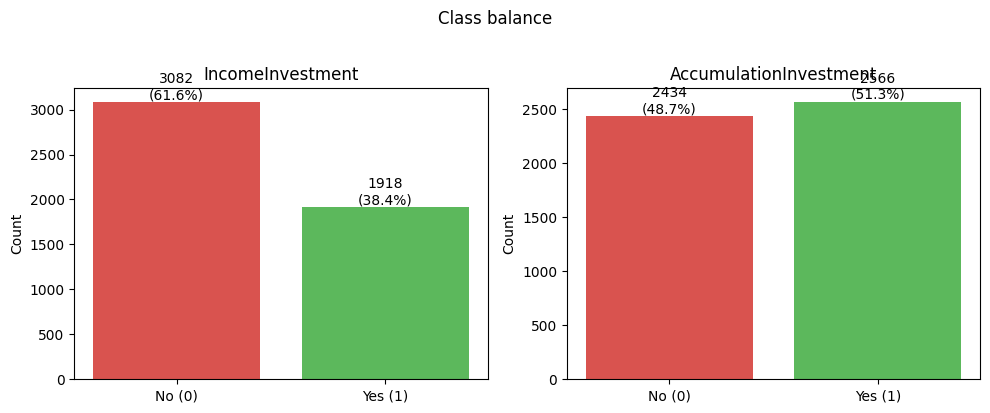

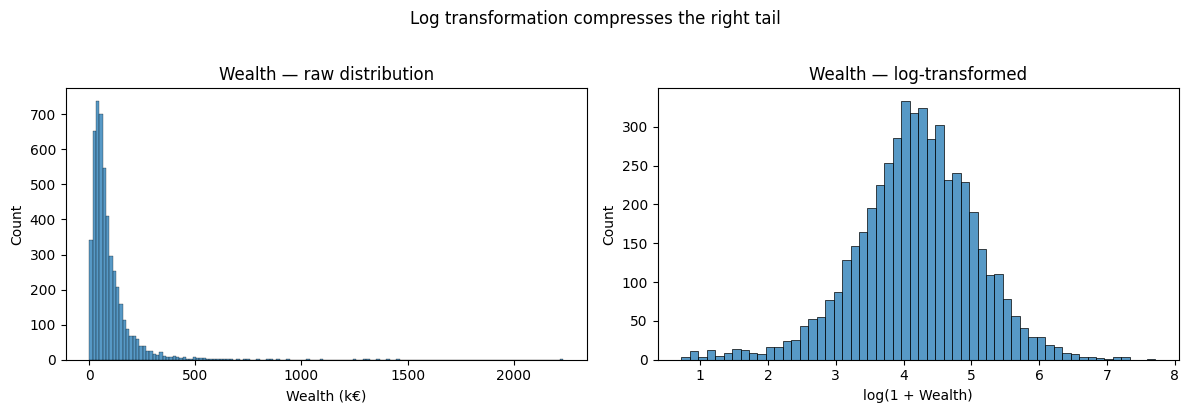

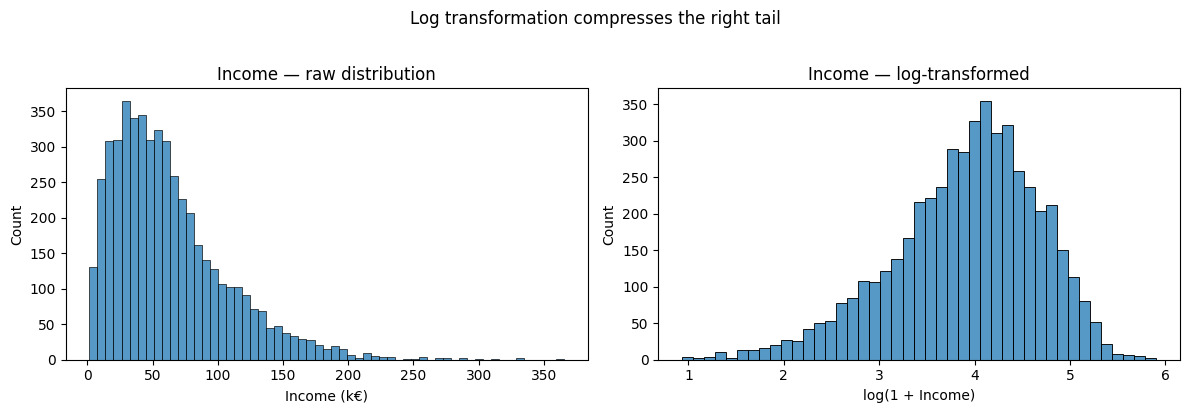

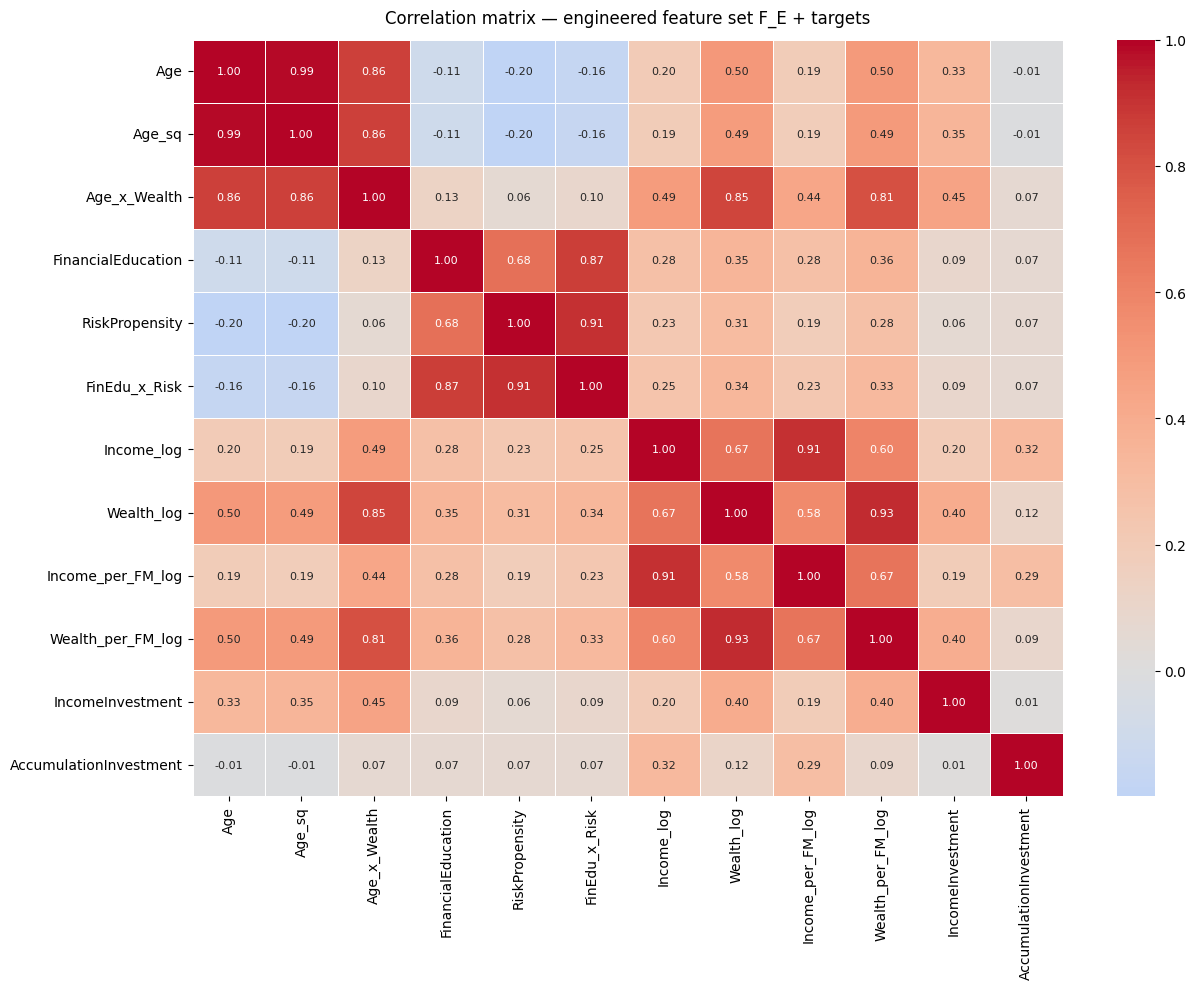

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build engineered features inline 

X = pd.DataFrame({
    'Age'               : needs_df['Age'],
    'Age_sq'            : needs_df['Age'] ** 2,
    'Age_x_Wealth'      : needs_df['Age'] * np.log1p(needs_df['Wealth']),
    'FinancialEducation': needs_df['FinancialEducation'],
    'RiskPropensity'    : needs_df['RiskPropensity'],
    'FinEdu_x_Risk'     : needs_df['FinancialEducation'] * needs_df['RiskPropensity'],
    'Income_log'        : np.log1p(needs_df['Income']),
    'Wealth_log'        : np.log1p(needs_df['Wealth']),
    'Income_per_FM_log' : np.log1p(needs_df['Income'] / needs_df['FamilyMembers']),
    'Wealth_per_FM_log' : np.log1p(needs_df['Wealth'] / needs_df['FamilyMembers']),
})

# Class balance 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, target in zip(axes, ['IncomeInvestment', 'AccumulationInvestment']):
    counts = needs_df[target].value_counts().sort_index()
    ax.bar(['No (0)', 'Yes (1)'], counts.values, color=['#d9534f', '#5cb85c'])
    ax.set_title(target)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, f'{v}\n({v/len(needs_df):.1%})', ha='center', fontsize=10)
plt.suptitle('Class balance', y=1.02)
plt.tight_layout()
plt.show()

# Wealth: raw vs log 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(needs_df['Wealth'], kde=False, ax=ax1)
ax1.set_title('Wealth — raw distribution')
ax1.set_xlabel('Wealth (k€)')
sns.histplot(np.log1p(needs_df['Wealth']), kde=False, ax=ax2)
ax2.set_title('Wealth — log-transformed')
ax2.set_xlabel('log(1 + Wealth)')
plt.suptitle('Log transformation compresses the right tail', y=1.02)
plt.tight_layout()
plt.show()

# Income: raw vs log 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(needs_df['Income'], kde=False, ax=ax1)
ax1.set_title('Income — raw distribution')
ax1.set_xlabel('Income (k€)')
sns.histplot(np.log1p(needs_df['Income']), kde=False, ax=ax2)
ax2.set_title('Income — log-transformed')
ax2.set_xlabel('log(1 + Income)')
plt.suptitle('Log transformation compresses the right tail', y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap — engineered feature set + targets 
X_corr = pd.concat(
    [X, needs_df[['IncomeInvestment', 'AccumulationInvestment']]],
    axis=1
)

plt.figure(figsize=(13, 10))
sns.heatmap(
    X_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8},
)
plt.title('Correlation matrix — engineered feature set F_E + targets', pad=12)
plt.tight_layout()
plt.show()


Class balance is checked first because it determines which metrics are meaningful. Both targets
are moderately imbalanced: IncomeInvestment at 38% positive, AccumulationInvestment at 51%.
The latter is effectively balanced; the former requires targeted correction in models that are
sensitive to class ratios.

Two plot types were deliberately excluded. Q-Q plots test for normality, which is not assumed
by any model in the pipeline. Full pairplots with 10 engineered features produce 100 subplots —
visually intractable and redundant with the correlation matrix already present.

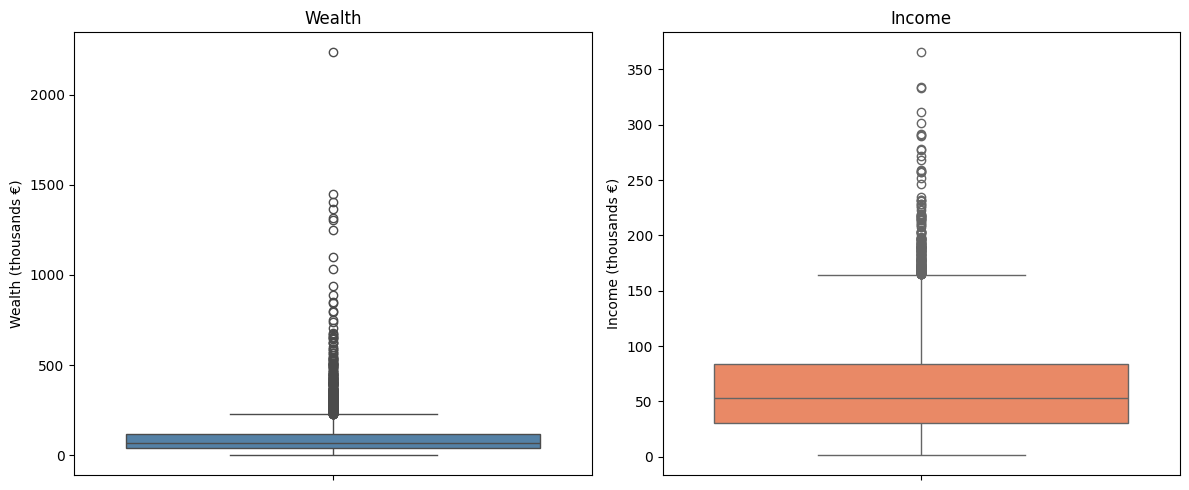

In [21]:
# BOX PLOTS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=needs_df['Wealth'], ax=axes[0], color='steelblue')
axes[0].set_title('Wealth')
axes[0].set_ylabel('Wealth (thousands €)')

sns.boxplot(y=needs_df['Income'], ax=axes[1], color='coral')
axes[1].set_title('Income')
axes[1].set_ylabel('Income (thousands €)')

plt.tight_layout()
plt.show()

Both variables show severe right skew and extreme outliers — Wealth up to €2.2M, Income up to
€365k. This reflects real-world wealth distribution, closer to a power law than a Gaussian.
Log transformation is the appropriate response and is applied in `build_features()`.

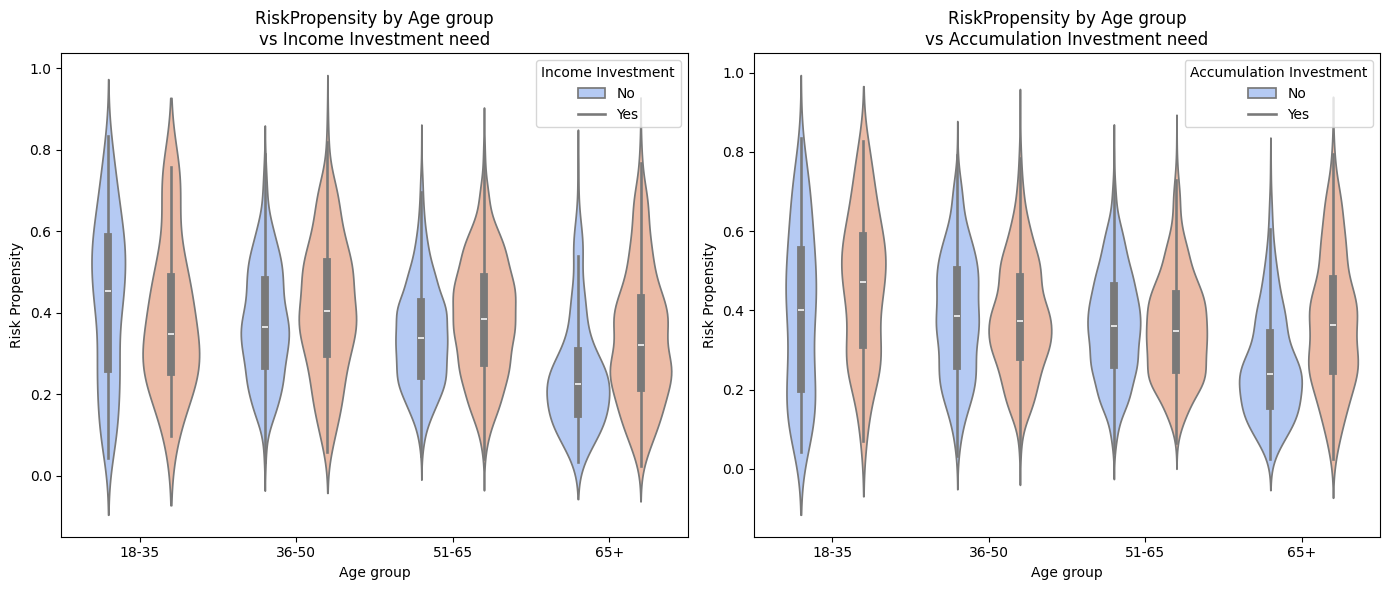

In [22]:
# VIOLIN PLOTS
needs_df['AgeBin'] = pd.cut(
    needs_df['Age'],
    bins=[18, 35, 50, 65, 100],
    labels=['18-35', '36-50', '51-65', '65+']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(
    data=needs_df, x='AgeBin', y='RiskPropensity',
    hue='IncomeInvestment', dodge=True, palette='coolwarm', ax=axes[0]
)
axes[0].set_title('RiskPropensity by Age group\nvs Income Investment need')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('Risk Propensity')
axes[0].legend(title='Income Investment', labels=['No', 'Yes'])

sns.violinplot(
    data=needs_df, x='AgeBin', y='RiskPropensity',
    hue='AccumulationInvestment', dodge=True, palette='coolwarm', ax=axes[1]
)
axes[1].set_title('RiskPropensity by Age group\nvs Accumulation Investment need')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Risk Propensity')
axes[1].legend(title='Accumulation Investment', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

# AgeBin is a visualization tool only — not a feature
needs_df.drop(columns=['AgeBin'], inplace=True)

Among clients aged 65+, those with `IncomeInvestment = 1` show *higher* risk propensity than
those with `IncomeInvestment = 0` — reversing the pattern seen in younger cohorts. This is
consistent with the lifecycle hypothesis: wealthier elderly clients can afford more risk while
still seeking income products. For `AccumulationInvestment`, age group has virtually no effect;
distribution shapes are nearly identical across all brackets, confirming the weaker signal
structure identified in the correlation matrix.

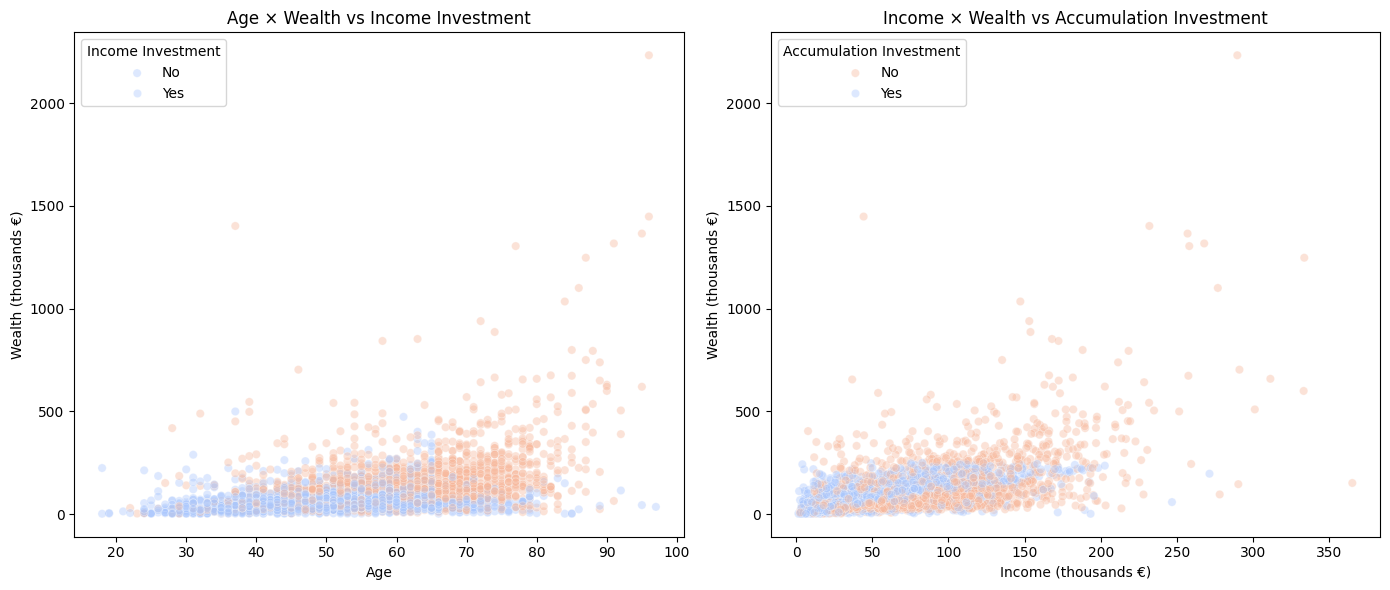

In [24]:
# SCATTER PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=needs_df, x='Age', y='Wealth',
    hue='IncomeInvestment', palette='coolwarm',
    alpha=0.4, ax=axes[0]
)
axes[0].set_title('Age × Wealth vs Income Investment')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Wealth (thousands €)')
axes[0].legend(title='Income Investment', labels=['No', 'Yes'])

sns.scatterplot(
    data=needs_df, x='Income', y='Wealth',
    hue='AccumulationInvestment', palette='coolwarm',
    alpha=0.4, ax=axes[1]
)
axes[1].set_title('Income × Wealth vs Accumulation Investment')
axes[1].set_xlabel('Income (thousands €)')
axes[1].set_ylabel('Wealth (thousands €)')
axes[1].legend(title='Accumulation Investment', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

`IncomeInvestment = 1` clients show a tendency to concentrate toward higher Age and higher
Wealth jointly — the orange cluster is denser in the upper-right of the left plot, consistent
with the lifecycle hypothesis and motivating the `Age_x_Wealth` interaction feature (r = 0.45
with target).

For `AccumulationInvestment`, the two classes overlap substantially across both axes. The
separation, while weak visually, tends to follow the Income axis more than the Wealth axis —
consistent with the correlation matrix finding that Income\_log (r = 0.32) is a stronger
marginal predictor of accumulation need than Wealth\_log (r = 0.12). This motivates retaining
Income and Wealth as separate features rather than collapsing them into a ratio.

### Feature Engineering

All features are built from financial theory first, then validated against the correlation
structure observed in the EDA above. The engineered set — which fully replaces the professor's
baseline — falls into two conceptually distinct groups.

The first group captures lifecycle dynamics. IncomeInvestment is driven by Age and Wealth
jointly, not independently: elderly and wealthy clients are the primary candidates for income
products. `Age_sq` encodes the non-linear acceleration of this need after age 65, visible in
the violin plots as a steeper divergence between need groups in the oldest cohort. `Age_x_Wealth`
captures the interaction directly and is the strongest predictor in the set at r = 0.45 with
the IncomeInvestment target, substantially above either Age (r = 0.33) or Wealth_log (r = 0.40)
alone.

The second group captures savings capacity. AccumulationInvestment is driven by Income, not Age.
Per-capita versions of Income and Wealth — `Income_per_FM_log` and `Wealth_per_FM_log` — are
more informative than gross figures for multi-member households: a household income of €80k
has very different implications depending on whether it supports two or five people. Despite
their high correlation with the gross log-transformed variables (r = 0.91 and r = 0.93
respectively), these correlations are materially below 1.0, confirming that FamilyMembers
introduces genuine additional signal and the per-capita features are not redundant with their
gross counterparts. `FinEdu_x_Risk` captures the sophisticated investor profile — clients who
are both financially literate and deliberate in their risk appetite — providing Logistic
Regression with an explicit interaction it cannot reconstruct from two correlated main effects.

Two variables are excluded entirely. Gender has correlation below 0.015 with both targets and
carries no predictive signal. Raw FamilyMembers is superseded by the per-capita ratio features;
retaining it alongside them would be redundant.

On data leakage: all scalers are fitted exclusively on the training set and applied to the test
set using those parameters. Raw feature construction — log transforms, ratios, interaction terms
— involves no statistical fitting and is safe to apply before splitting. This corrects a bug
in the professor's original notebook, where MinMaxScaler was fitted on the full dataset before
splitting, leaking test set statistics into the scaler.

On multicollinearity: Age, Age_sq, and Age_x_Wealth are correlated by construction. This is
intentional and not problematic. Tree-based models are invariant to multicollinearity by design
— split decisions depend on marginal feature distributions, not inter-feature correlations. For
Logistic Regression, L1 regularization zeros out redundant terms automatically. For SVM,
MinMaxScaler ensures no single feature dominates the kernel distance computation. The
correlation heatmap below confirms the expected structure among lifecycle features and rules
out unexpected collinearity elsewhere in the set.

The full feature set is formally defined, formula-checked, and asserted in `data_sanity.ipynb`,
which writes the final matrices `F_E.pkl` and `F_B.pkl` to `data/feature_store/` as the single
source of truth consumed by all model notebooks.